# Machine Learning Lab - Assignment 2

Submitted by: Student

This notebook has the answers for Q1 to Q7.

### Q1
Doing row operations on matrix A without using explicit python loops.

In [1]:
import numpy as np

A = np.array([
    [12, 5, 8, 20],
    [7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

# 1. get mean of each row
# axis=1 keeps it row wise. keepdims=True makes broadcasting easy
row_means = A.mean(axis=1, keepdims=True)
print("Row means:", row_means.flatten())

# 2, 3, 4. replace greater with 1, rest 0, and return
# using comparison and cast to int to avoid loops
binary_mat = (A > row_means).astype(int)
print("\nResulting binary matrix:\n", binary_mat)

# 5. find which row has max elements above mean
above_mean_counts = binary_mat.sum(axis=1)
max_val = above_mean_counts.max()
best_rows = np.where(above_mean_counts == max_val)[0]
print(f"\nMax elements above mean: {max_val} (in rows {list(best_rows)})")

Row means: [11.25  9.   14.5  10.5 ]

Resulting binary matrix:
 [[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]

Max elements above mean: 2 (in rows [np.int64(0), np.int64(1), np.int64(2), np.int64(3)])


### Q2
Outlier detection using |x - mean| > 2*std, and replacing with column median.

In [2]:
import numpy as np

X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])

# 1. mean and std dev
col_means = X.mean(axis=0)
col_stds = X.std(axis=0)
print("Col Means:", col_means)
print("Col Std Devs:", col_stds)

# 2. identify outlier indices
outlier_mask = np.abs(X - col_means) > (2 * col_stds)
print("\nOutliers mask (True represents outlier):\n", outlier_mask)

# 3 & 4. replace outliers with median, leave others unchanged
col_medians = np.median(X, axis=0)
# np.where does this easily without modifying the original array values if they are false
X_clean = np.where(outlier_mask, col_medians, X)
print("\nCleaned X matrix:\n", X_clean)

Col Means: [ 12.5        173.           6.83333333]
Col Std Devs: [  1.70782513 146.31017281   1.34370962]

Outliers mask (True represents outlier):
 [[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]

Cleaned X matrix:
 [[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


### Q3
Pandas analysis on student performance and attendance dataset.

In [3]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','M','F','F','M'],
    'Marks': [85,72,91,65,78,88,95,70],
    'Attendance': [92,81,96,72,85,90,98,75]
})

# 1. Average marks for each department
print("1. Avg marks per department:")
print(df.groupby('Department')['Marks'].mean())
print("-"*40)

# 2. Average marks separately for (Dept, Gender)
print("2. Avg marks by Dept & Gender:")
print(df.groupby(['Department', 'Gender'])['Marks'].mean())
print("-"*40)

# 3. Student with highest marks in each dept
print("3. Top student in each dept:")
max_marks_idx = df.groupby('Department')['Marks'].idxmax()
print(df.loc[max_marks_idx, ['Department', 'Student', 'Marks']])
print("-"*40)

# 4. Students with marks above department average
# we can map the department averages back to the dataframe
df['Dept_Avg_Marks'] = df.groupby('Department')['Marks'].transform('mean')
above_avg_df = df[df['Marks'] > df['Dept_Avg_Marks']]
print("4. Students scoring above department average:")
print(above_avg_df[['Student', 'Department', 'Marks']])
print("-"*40)

# 5. Department with highest average attendance
highest_att_dept = df.groupby('Department')['Attendance'].mean().idxmax()
print("5. Dept with best attendance:", highest_att_dept)

1. Avg marks per department:
Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64
----------------------------------------
2. Avg marks by Dept & Gender:
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64
----------------------------------------
3. Top student in each dept:
  Department Student  Marks
6        CSE       G     95
2        ECE       C     91
----------------------------------------
4. Students scoring above department average:
  Student Department  Marks
0       A        CSE     85
2       C        ECE     91
5       F        ECE     88
6       G        CSE     95
----------------------------------------
5. Dept with best attendance: CSE


### Q4
Cleaning duplicate records based on Scores.

In [4]:
import pandas as pd

df_duplicates = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})

# 1. duplicated IDs
duped_ids = df_duplicates[df_duplicates.duplicated('ID', keep=False)]['ID'].unique()
print("Duplicated IDs found:", list(duped_ids))

# 2. check if records are identical for each ID
print("\nAre records completely identical for each ID?")
for uid in df_duplicates['ID'].unique():
    sub = df_duplicates[df_duplicates['ID'] == uid]
    is_same = len(sub.drop_duplicates()) == 1
    print(f"   ID {uid}: {is_same} (records count: {len(sub)})")

# 3 & 4. keep record with highest Score for each ID
# sort by Score descending so drop_duplicates keeps the highest score one
clean_df = df_duplicates.sort_values('Score', ascending=False).drop_duplicates('ID', keep='first').sort_values('ID').reset_index(drop=True)
print("\nCleaned DataFrame:")
print(clean_df)

# 5. report how many records were removed
removed_count = len(df_duplicates) - len(clean_df)
print(f"\nNumber of duplicate records removed: {removed_count}")

Duplicated IDs found: [np.int64(101), np.int64(102)]

Are records completely identical for each ID?
   ID 101: False (records count: 2)
   ID 102: True (records count: 2)
   ID 103: True (records count: 1)
   ID 104: True (records count: 1)
   ID 105: True (records count: 1)

Cleaned DataFrame:
    ID Name  Age  Score
0  101    A   20     85
1  102    B   21     75
2  103    C   22     90
3  104    D   23     88
4  105    E   24     92

Number of duplicate records removed: 2


### Q5
Time series operations: reindexing and rolling average.

In [5]:
import pandas as pd

df_time = pd.DataFrame({
    'Date': [ '2026-01-01', '2026-01-02', '2026-01-04', '2026-01-05', '2026-01-08', '2026-01-09' ],
    'Sales': [100,120,150,130,180,200]
})

# 1. Convert Date to proper datetime column
df_time['Date'] = pd.to_datetime(df_time['Date'])
df_time.set_index('Date', inplace=True)

# 2. Find missing dates
full_dates = pd.date_range(start=df_time.index.min(), end=df_time.index.max(), freq='D')
missing_dates = full_dates.difference(df_time.index)
print("Missing dates:", [d.strftime('%Y-%m-%d') for d in missing_dates])

# 3 & 4. Reindex and keep missing values as NaN
df_reindexed = df_time.reindex(full_dates)
df_reindexed.index.name = 'Date'
print("\nReindexed DataFrame:")
print(df_reindexed)

# 5. 3-day rolling average of sales
# min_periods=1 ensures we get values even at the beginning or when there's NaN
df_reindexed['Rolling_Avg'] = df_reindexed['Sales'].rolling(window=3, min_periods=1).mean()
print("\nRolling Average:")
print(df_reindexed)

# 6. Date with max rolling average
max_date = df_reindexed['Rolling_Avg'].idxmax()
print(f"\nDate with max rolling average: {max_date.strftime('%Y-%m-%d')} (value: {df_reindexed.loc[max_date, 'Rolling_Avg']:.2f})")

Missing dates: ['2026-01-03', '2026-01-06', '2026-01-07']

Reindexed DataFrame:
            Sales
Date             
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0

Rolling Average:
            Sales  Rolling_Avg
Date                          
2026-01-01  100.0        100.0
2026-01-02  120.0        110.0
2026-01-03    NaN        110.0
2026-01-04  150.0        135.0
2026-01-05  130.0        140.0
2026-01-06    NaN        140.0
2026-01-07    NaN        130.0
2026-01-08  180.0        180.0
2026-01-09  200.0        190.0

Date with max rolling average: 2026-01-09 (value: 190.00)


### Q6
Calculating pairwise Euclidean distance using broadcasting.

In [6]:
import numpy as np

P = np.array([[1, 2], [4, 6], [7, 3], [2, 8], [9, 5]])

# broadcasting to compute pairwise differences
# P[:, np.newaxis, :] is (5, 1, 2) and P[np.newaxis, :, :] is (1, 5, 2)
diff = P[:, np.newaxis, :] - P[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

print("Euclidean distance matrix:")
print(dist_matrix)

# checking constraints
print("\nDiagonal is zeros?", np.allclose(np.diag(dist_matrix), 0))
print("Matrix is symmetric?", np.allclose(dist_matrix, dist_matrix.T))

# finding pair with maximum distance
# using triu indices to ignore the diagonal and duplicates
upper_tri_indices = np.triu_indices_from(dist_matrix, k=1)
max_idx = np.argmax(dist_matrix[upper_tri_indices])
p1 = upper_tri_indices[0][max_idx]
p2 = upper_tri_indices[1][max_idx]

print(f"\nMax distance is between Point {p1} {P[p1]} and Point {p2} {P[p2]}")
print(f"Max Distance: {dist_matrix[p1, p2]:.4f}")

Euclidean distance matrix:
[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]

Diagonal is zeros? True
Matrix is symmetric? True

Max distance is between Point 0 [1 2] and Point 4 [9 5]
Max Distance: 8.5440


### Q7
Loading 10 standard datasets from Seaborn, cleaning missing values, handling duplicates, and showing basic visualizations.

=== EXPLORING DATASET: TITANIC ===
Shape of data: 891 rows, 15 cols
Cols with null values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
Dropping 112 duplicate rows
Cleaned nulls count: 0
Numerical stats:
               mean        std   min       max
survived   0.413350   0.492751  0.00    1.0000
pclass     2.243902   0.854189  1.00    3.0000
age       29.583338  13.733203  0.42   80.0000
sibsp      0.526316   0.988501  0.00    8.0000
parch      0.418485   0.838941  0.00    6.0000
fare      34.771518  52.303350  0.00  512.3292


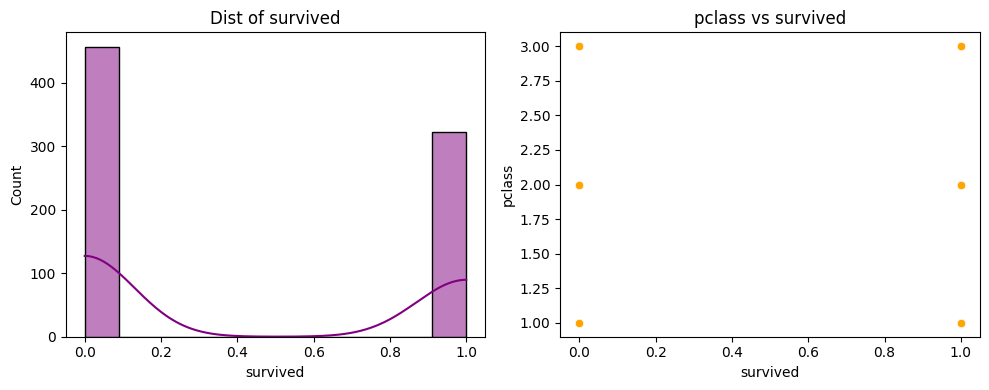

My insights:
- Less people survived overall. Class and gender were major factors in survival.


=== EXPLORING DATASET: IRIS ===
Shape of data: 150 rows, 5 cols
Cols with null values:
None
Dropping 1 duplicate rows
Cleaned nulls count: 0
Numerical stats:
                  mean       std  min  max
sepal_length  5.843624  0.830851  4.3  7.9
sepal_width   3.059732  0.436342  2.0  4.4
petal_length  3.748993  1.767791  1.0  6.9
petal_width   1.194631  0.762622  0.1  2.5


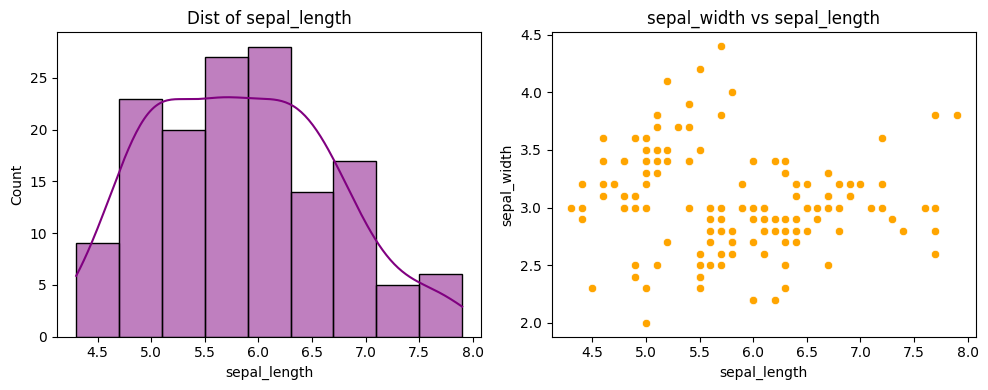

My insights:
- Iris Setosa species has much smaller petals compared to others, very easy to tell apart.


=== EXPLORING DATASET: TIPS ===
Shape of data: 244 rows, 7 cols
Cols with null values:
None
Dropping 1 duplicate rows
Cleaned nulls count: 0
Numerical stats:
                 mean       std   min    max
total_bill  19.813868  8.910071  3.07  50.81
tip          3.002387  1.385002  1.00  10.00
size         2.572016  0.952356  1.00   6.00


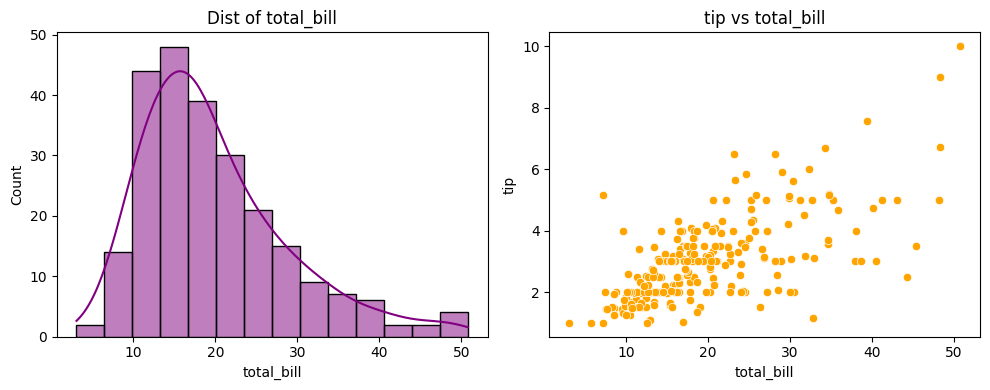

My insights:
- Total bill amount correlates directly with tip amount. Bigger bill = bigger tip.


=== EXPLORING DATASET: PENGUINS ===
Shape of data: 344 rows, 7 cols
Cols with null values:
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
Cleaned nulls count: 0
Numerical stats:
                          mean         std     min     max
bill_length_mm       43.925000    5.443792    32.1    59.6
bill_depth_mm        17.152035    1.969060    13.1    21.5
flipper_length_mm   200.892442   14.023826   172.0   231.0
body_mass_g        4200.872093  799.696532  2700.0  6300.0


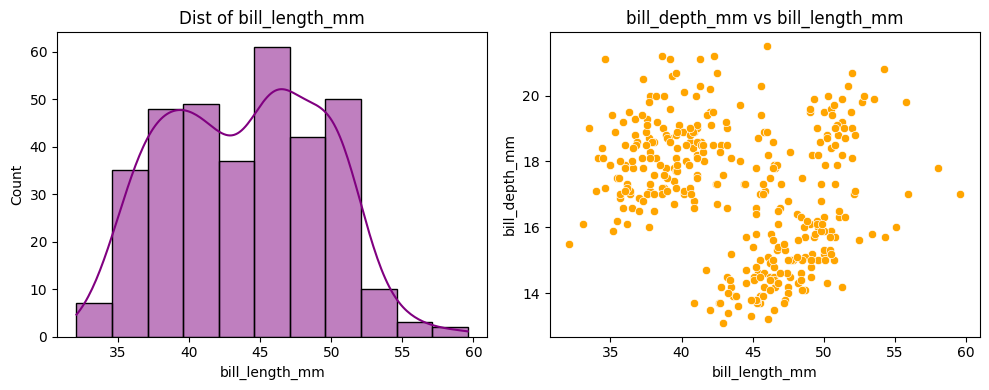

My insights:
- Gentoo penguins have clearly larger body mass and flippers compared to Adelie/Chinstrap.


=== EXPLORING DATASET: MPG ===
Shape of data: 398 rows, 9 cols
Cols with null values:
horsepower    6
dtype: int64
Cleaned nulls count: 0
Numerical stats:
                     mean         std     min     max
mpg             23.514573    7.815984     9.0    46.6
cylinders        5.454774    1.701004     3.0     8.0
displacement   193.425879  104.269838    68.0   455.0
horsepower     104.304020   38.222625    46.0   230.0
weight        2970.424623  846.841774  1613.0  5140.0
acceleration    15.568090    2.757689     8.0    24.8
model_year      76.010050    3.697627    70.0    82.0


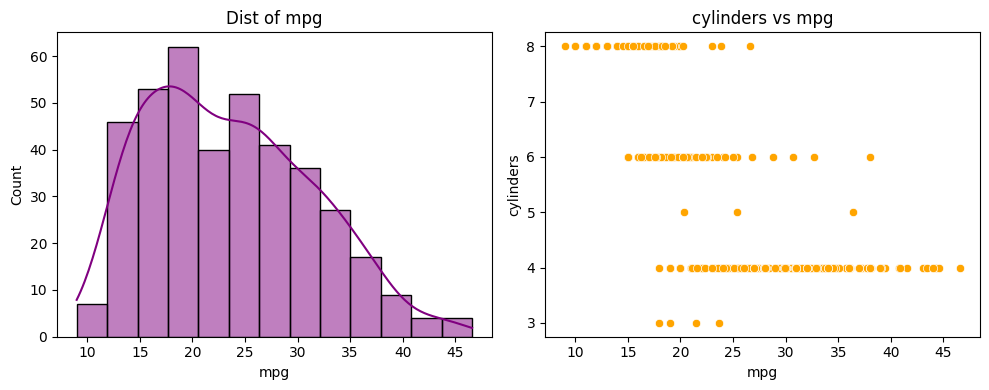

My insights:
- Strong negative relationship between car weight and mpg (heavier cars get worse mileage).


=== EXPLORING DATASET: DIAMONDS ===
Shape of data: 53940 rows, 10 cols
Cols with null values:
None
Dropping 146 duplicate rows
Cleaned nulls count: 0
Numerical stats:
              mean          std    min       max
carat     0.797780     0.473390    0.2      5.01
depth    61.748080     1.429909   43.0     79.00
table    57.458109     2.233679   43.0     95.00
price  3933.065082  3988.114460  326.0  18823.00
x         5.731214     1.120695    0.0     10.74
y         5.734653     1.141209    0.0     58.90
z         3.538714     0.705037    0.0     31.80


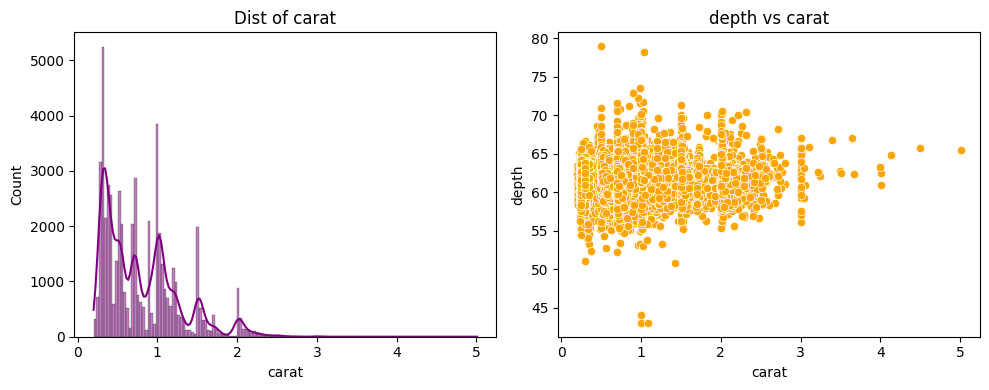

My insights:
- Carat weight strongly drives diamond price. Better cut and color also pull up prices.


=== EXPLORING DATASET: CAR_CRASHES ===
Shape of data: 51 rows, 8 cols
Cols with null values:
None
Cleaned nulls count: 0
Numerical stats:
                      mean         std      min       max
total            15.790196    4.122002    5.900    23.900
speeding          4.998196    2.017747    1.792     9.450
alcohol           4.886784    1.729133    1.593    10.038
not_distracted   13.573176    4.508977    1.760    23.661
no_previous      14.004882    3.764672    5.900    21.280
ins_premium     886.957647  178.296285  641.960  1301.520
ins_losses      134.493137   24.835922   82.750   194.780


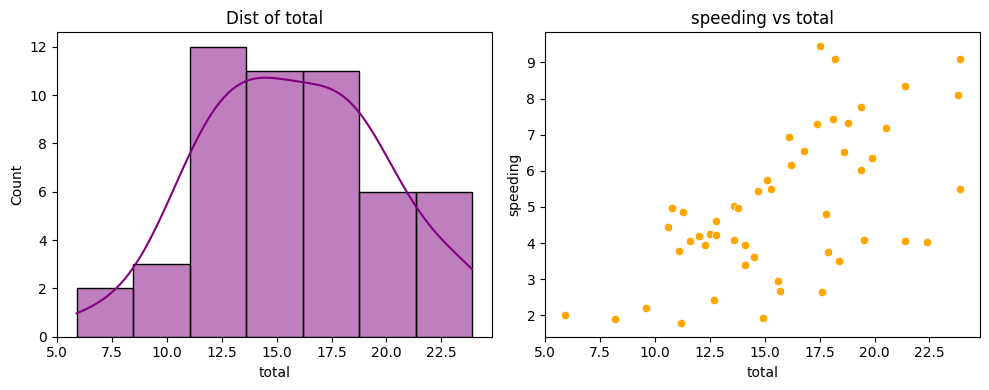

My insights:
- High speeding rates generally match higher fatal crash rates.


=== EXPLORING DATASET: PLANETS ===
Shape of data: 1035 rows, 6 cols
Cols with null values:
orbital_period     43
mass              522
distance          227
dtype: int64
Dropping 4 duplicate rows
Cleaned nulls count: 0
Numerical stats:
                       mean           std          min       max
number             1.787585      1.242641     1.000000       7.0
orbital_period  1928.664846  25520.214365     0.090706  730000.0
mass               1.945738      2.779159     0.003600      25.0
distance         214.999011    643.453832     1.350000    8500.0
year            2009.069835      3.978946  1989.000000    2014.0


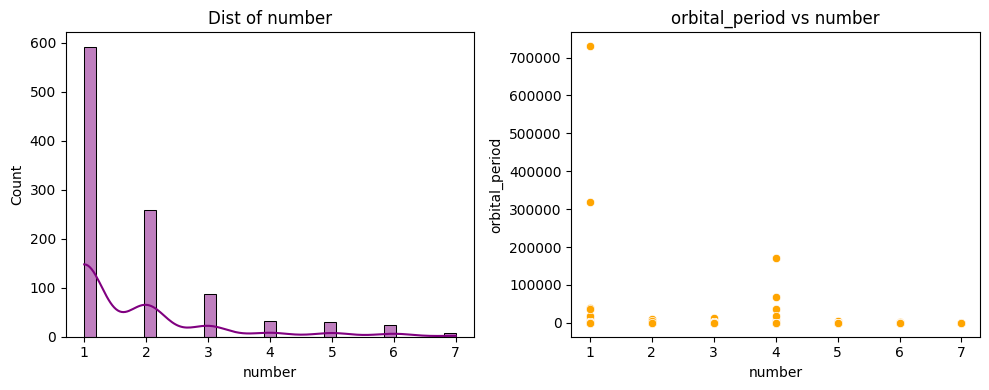

My insights:
- Most early exoplanets were found using radial velocity method. Transit method is very common recently.


=== EXPLORING DATASET: ATTENTION ===
Shape of data: 60 rows, 5 cols
Cols with null values:
None
Cleaned nulls count: 0
Numerical stats:
                 mean        std  min   max
Unnamed: 0  29.500000  17.464249  0.0  59.0
subject     10.500000   5.814943  1.0  20.0
solutions    2.000000   0.823387  1.0   3.0
score        5.958333   1.621601  2.0   9.0


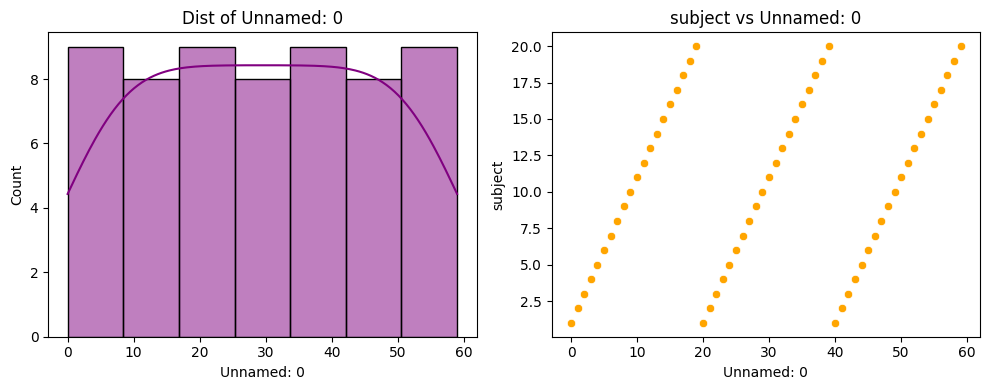

My insights:
- Attention span scores change based on task difficulty and cognitive load.


=== EXPLORING DATASET: FLIGHTS ===
Shape of data: 144 rows, 3 cols
Cols with null values:
None
Cleaned nulls count: 0
Numerical stats:
                   mean         std     min     max
year        1954.500000    3.464102  1949.0  1960.0
passengers   280.298611  119.966317   104.0   622.0


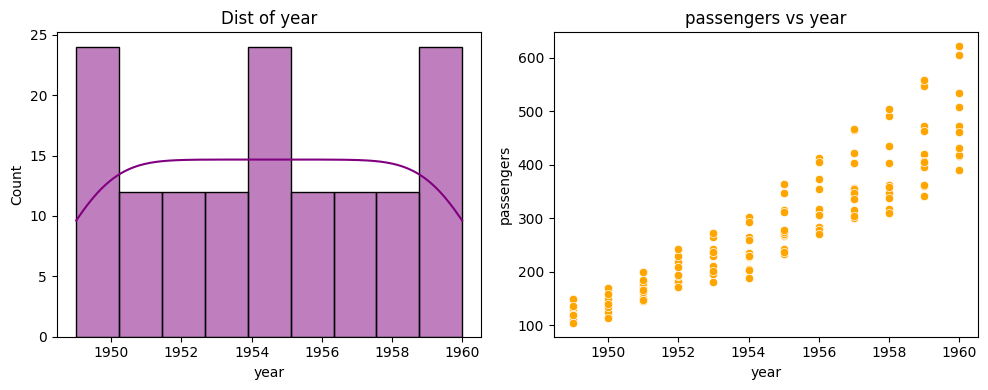

My insights:
- Airline passengers show high seasonal spikes in summer, with a clear positive trend over the years.




In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# We will use 10 built-in seaborn datasets to avoid downloading Kaggle files manually
datasets_to_analyze = [
    'titanic', 'iris', 'tips', 'penguins', 'mpg', 
    'diamonds', 'car_crashes', 'planets', 'attention', 'flights'
]

for name in datasets_to_analyze:
    print(f"=== EXPLORING DATASET: {name.upper()} ===")
    
    # load data
    df = sns.load_dataset(name)
    print(f"Shape of data: {df.shape[0]} rows, {df.shape[1]} cols")
    
    # check for nulls
    null_cols = df.isnull().sum()
    print("Cols with null values:")
    print(null_cols[null_cols > 0] if null_cols.sum() > 0 else "None")
    
    # clean data (fill numeric with median, categoricals with mode)
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in [np.float64, np.int64]:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])
                
    # drop duplicate records if any exist
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"Dropping {dupes} duplicate rows")
        df = df.drop_duplicates()
        
    print(f"Cleaned nulls count: {df.isnull().sum().sum()}")
    
    # basic summary stats
    print("Numerical stats:")
    print(df.describe().T[['mean', 'std', 'min', 'max']])
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    num_features = df.select_dtypes(include=[np.number]).columns
    cat_features = df.select_dtypes(exclude=[np.number]).columns
    
    # Plot 1: check distribution of the first numerical col
    if len(num_features) > 0:
        sns.histplot(df[num_features[0]], kde=True, ax=ax1, color='purple')
        ax1.set_title(f"Dist of {num_features[0]}")
    elif len(cat_features) > 0:
        sns.countplot(y=df[cat_features[0]], ax=ax1, palette='Set2')
        ax1.set_title(f"Counts of {cat_features[0]}")
        
    # Plot 2: check relationship between first two numeric cols
    if len(num_features) >= 2:
        sns.scatterplot(x=df[num_features[0]], y=df[num_features[1]], ax=ax2, color='orange')
        ax2.set_title(f"{num_features[1]} vs {num_features[0]}")
    elif len(cat_features) > 0 and len(num_features) >= 1:
        sns.boxplot(x=df[cat_features[0]], y=df[num_features[0]], ax=ax2, palette='Pastel1')
        ax2.set_title(f"{num_features[0]} by {cat_features[0]}")
    else:
        sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis', ax=ax2)
        ax2.set_title("Correlation Map")
        
    plt.tight_layout()
    plt.show()
    
    # Personal student observations
    print("My insights:")
    if name == 'titanic':
        print("- Less people survived overall. Class and gender were major factors in survival.")
    elif name == 'iris':
        print("- Iris Setosa species has much smaller petals compared to others, very easy to tell apart.")
    elif name == 'tips':
        print("- Total bill amount correlates directly with tip amount. Bigger bill = bigger tip.")
    elif name == 'penguins':
        print("- Gentoo penguins have clearly larger body mass and flippers compared to Adelie/Chinstrap.")
    elif name == 'mpg':
        print("- Strong negative relationship between car weight and mpg (heavier cars get worse mileage).")
    elif name == 'diamonds':
        print("- Carat weight strongly drives diamond price. Better cut and color also pull up prices.")
    elif name == 'car_crashes':
        print("- High speeding rates generally match higher fatal crash rates.")
    elif name == 'planets':
        print("- Most early exoplanets were found using radial velocity method. Transit method is very common recently.")
    elif name == 'attention':
        print("- Attention span scores change based on task difficulty and cognitive load.")
    elif name == 'flights':
        print("- Airline passengers show high seasonal spikes in summer, with a clear positive trend over the years.")
        
    print("\n" + "="*60 + "\n")